# Assignment 8 — Robustness Analysis

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  


---

## Learning Outcomes

After completing this assignment you will be able to:

1. Re-evaluate a set of Pareto-optimal policies across an ensemble of climate
   scenarios.

2. Compute and interpret **satisficing scores** — the fraction of scenarios in
   which a policy meets an acceptable threshold on all objectives simultaneously.

3. Compute and interpret **minimax regret** — the worst-case loss a policy
   incurs relative to the best achievable outcome in each scenario.

---

## Assignment Overview

This assignment re-evaluates your Pareto-optimal policies by re-running JUSTICE across multiple climate scenarios (FAIR ensemble members) and applying two complementary robustness metrics:

- **Satisficing** — does the policy meet an acceptable threshold on every objective, across enough scenarios?
- **Minimax regret** — which policy has the smallest worst-case loss relative to what was achievable?

**What you will do**

- Run `run_reeval.py` to evaluate every policy under multiple climate scenarios
- Apply satisficing analysis — choose thresholds, compute scores, and visualise
- Apply minimax regret — compute worst-case performance 

**What you will need**

- Your **reference set** from Assignment 6 (the Pareto-optimal solutions)
- Your **config file** the one you used to run the optimization or optimizations

**What you will produce**

- A heatmap showing which objectives are hardest to satisfy
- A maximum regret ranking of all policies
- A CDF plot of worst-case regret across the Pareto front
- Your recommended solution based on the analysis

> **Scope note:** This is a simplified robustness analysis. A full robustness
> analysis would test policy performance across uncertainty in many parameters
> simultaneously, you can think of all the model assumptions, economic inputs, damage functions, and
> more. Here we vary only the climate uncertainty (FAIR ensemble members),
> holding everything else fixed. This is a meaningful first step, but keep in
> mind that the robustness scores you compute reflect climate uncertainty only,
> not the full uncertainty space the model operates in.

___

## Setup — Imports, paths, and model constants

In [14]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as _mpath
import seaborn as sns
#from justice.abatement.abatement_enerdata import AbatementEnerdata
from justice.objectives.objective_functions import years_above_temperature_threshold

# ── Patch matplotlib Path deepcopy ────────────────────────────────────────────
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))
_PLOTS_DIR   = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

# ── Objectives ────────────────────────────────────────────────────────────────
OBJECTIVES = ["welfare", "years_above_2C", "welfare_loss_damage", "welfare_loss_abatement"]
OBJ_LABELS = ["Welfare", "Yrs > 2°C", "WL Damage", "WL Abatement"]


print(f"Results root : {RESULTS_ROOT}")
print("Setup OK")


Results root : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results
Setup OK


## Step 1 — Re-evaluation using the EMA Workbench

To assess the robustness of your Pareto-optimal policies, you need to re-run JUSTICE for every policy under multiple climate scenarios. This is a computationally expensive operation — running it sequentially inside a notebook would take hours on a single core.

Instead, you can adapt the provided script [assignments_ema/run_reeval.py](assignments_ema/run_reeval.py), which runs the experiment in parallel using all available CPU cores and saves the results.

### 1.1. What the script does

The script uses the EMA Workbench (`perform_experiments`) to handle the full factorial experiment — every policy × every scenario.

These are the steps implemented in the script:

1. **Set up paths** — figures out where it lives on disk and builds paths to the JUSTICE model, the config file, and the results folder.

2. **Load your config file** — reads your model settings (start year, end year, timestep, scenario index, etc.) — the same settings used during optimisation.

3. **Compute model constants** — determines how many timesteps and regions the model has, and what shape the RBF parameters take (8 centers, 8 radii, 228 weights).

4. **Define the model wrapper** — wraps JUSTICE in a plain Python function that EMA Workbench calls once per (policy, scenario) pair. It must be at the top level of the script — not inside a notebook cell — so Python's multiprocessing system can distribute it to worker processes. Each call:
   - Receives the 244 RBF parameters and the climate ensemble index as inputs
   - Rebuilds the RBF and runs JUSTICE forward through time (identical to Assignment 7)
   - Returns the four objectives: welfare, years above 2°C, welfare loss from damage, and welfare loss from abatement

5. **Load the reference set** — reads your reference set CSV, and identifies the 244 lever columns (this is essentially what you need for the reruns).

6. **Check if results already exist** — if the output files are already on disk, the script exits immediately so you don't accidentally re-run a long computation.

7. **Register the model with EMA Workbench** — creates a `Model` object and declares:
   - **Uncertainties** — `climate_ensemble_index` (integer 1–1000): which FAIR climate trajectory to use. Varies across scenarios.
   - **Levers** — the 244 RBF parameters (centers, radii, weights). Vary across policies, fixed within each policy.
   - **Outcomes** — the four scalar objectives.

> **Note on objective directions:** In Assignment 4, `welfare_loss_damage` and
> `welfare_loss_abatement` were declared as `MAXIMIZE` during optimisation — this
> was an EMA Workbench convention for handling positive quantities, not a sign
> that higher losses are better. Here, with no optimiser involved, they are
> correctly declared as `MINIMIZE`: lower welfare loss is always better.

8. **Build policy and scenario lists** — creates one `Policy` object per row in the reference set and one `Scenario` object per selected FAIR ensemble member.

9. **Run in parallel** — distributes all (policy, scenario) combinations across CPU cores using `MultiprocessingEvaluator`.

10. **Reshape and save** — reorganises the results into two files:
    - **`<run_name>_<n_policies>p_<n_scenarios>s.npy`** — a 3D NumPy array of shape `(n_policies, n_scenarios, n_objectives)` with the four objective values for every combination. This is what the notebook uses for robustness analysis.
    - **`<run_name>_<n_policies>p_<n_scenarios>s_experiments.csv`** — a flat table recording the inputs (policy, scenario, lever values) for every run.


### 1.2. Running the script

**Step 1 — Update the script**

Open [assignments_ema/run_reeval.py](assignments_ema/run_reeval.py) and make the necessary changes, at the very least, you'll need to:

1. Replace `config_ssp245.json` with your own config
2. Replace `reference_set_utilitarian.csv` with your reference set.

**Step 2 — Run from the terminal**

Open a terminal in the `epa141a` folder and run:

```bash
# Quick test — verify everything works before a full run
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 10

# Full run (this will take several hours)
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 1000

# Limit cores if needed (e.g. leave one free for other work)
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 1000 --n_cores 4
```

> Tip: start running the script as is with a smoke test i.e. `--n_scenarios 5` to confirm your config and reference set paths are correct before implementing further changes and committing to a full run, which can take foreverr. 




In [15]:
import os
import re
import shutil
import pandas as pd

ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian_1_5_bs200_dec0101.csv")
#backup_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian_unclean_backup.csv")

#if not os.path.exists(backup_path):
 #   shutil.copy2(ref_path, backup_path)
  #  print(f"Backup saved to: {backup_path}")

df = pd.read_csv(ref_path)

objective_cols = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

clean = pd.DataFrame(index=df.index)

for prefix in ["center", "radii", "weights"]:
    indices = set()

    for col in df.columns:
        match = re.match(rf"^{prefix}[ _](\d+)$", col)
        if match:
            indices.add(int(match.group(1)))

    for i in sorted(indices):
        safe_col = f"{prefix}_{i}"
        space_col = f"{prefix} {i}"

        available = [c for c in [safe_col, space_col] if c in df.columns]

        values = df[available[0]]
        for col in available[1:]:
            values = values.combine_first(df[col])

        clean[safe_col] = values

for col in objective_cols:
    clean[col] = df[col]

missing = clean.isna().sum()
missing = missing[missing > 0]

print(f"Original shape: {df.shape}")
print(f"Clean shape:    {clean.shape}")

if not missing.empty:
    print("Columns with missing values:")
    print(missing)
    raise ValueError("Cleaned reference set still has missing values.")

clean.to_csv(ref_path, index=False)
print(f"Cleaned reference set written to: {ref_path}")

Original shape: (12, 248)
Clean shape:    (12, 248)
Cleaned reference set written to: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results\reference_set_utilitarian_1_5_bs200_dec0101.csv


In [10]:
# Run Assignment 8 re-evaluation fast by launching run_reeval.py as a separate
# parallel process using all CPU cores.
#
import os
import sys
import subprocess


# If this notebook is in assignments_ema/, repo root is one level up.
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

SCRIPT_PATH = os.path.join(REPO_ROOT, "assignments_ema", "run_reeval.py")

N_CORES = os.cpu_count()

# Use this for a quick check:
#N_SCENARIOS = 10
# Use this for the full run:
N_SCENARIOS = 1000

cmd = [
    sys.executable,
    SCRIPT_PATH,
    "--n_scenarios", str(N_SCENARIOS),
    "--n_cores", str(N_CORES),
]

# Prevent each worker process from also spawning many numerical-library threads.
# This avoids CPU oversubscription and is usually faster for multiprocessing.
env = os.environ.copy()
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["OPENBLAS_NUM_THREADS"] = "1"
env["NUMEXPR_NUM_THREADS"] = "1"

print("Running command:")
print(" ".join(cmd))
print(f"\nUsing {N_CORES} CPU cores")

process = subprocess.Popen(
    cmd,
    cwd=REPO_ROOT,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(line, end="")

return_code = process.wait()

if return_code == 0:
    print("\nRe-evaluation completed successfully.")
else:
    raise RuntimeError(f"Re-evaluation failed with return code {return_code}")

Running command:
c:\Users\marij\miniconda3\envs\epa141a\python.exe c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\run_reeval.py --n_scenarios 1000 --n_cores 16

Using 16 CPU cores
Using reference set: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_refs\reference_set_utilitarian_1_5_bs200_dec0101.csv
Policies  : 12
Scenarios : 1000  (FAIR indices: [np.int64(1), np.int64(2), np.int64(3)] … [np.int64(998), np.int64(999), np.int64(1000)])
Cache     : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_refs\reeval_utilitarian_bs200_dec0101_12p_1000s.npy

Starting MultiprocessingEvaluator with 16 cores …
[MainProcess/INFO] pool started with 16 workers
[MainProcess/INFO] performing 1000 scenarios * 12 policies * 1 model(s) = 12000 experiments

100%|██████████████████████████████████| 12000/12000 [1:04:14<00:00,  3.11it/s]
[MainProcess/INFO] experiments finished


## Step 2 — Satisficing analysis

A policy **satisfices** in a scenario if it meets an acceptable threshold on
**every** objective simultaneously. The **satisficing score** is the fraction
of scenarios in which a policy does this.

**Task 1. Choose your thresholds**

For each of the four objectives, decide what counts as "acceptable" performance.
You must define one threshold per objective and justify your choice. Consider:

- Is there an external standard you can use? For example, the Paris Agreement
  temperature target, which could directly inform your threshold?
- If no external standard exists, you can establish a specific percentile across all policies and scenarios.
- Should some objectives be held to a stricter standard than others? Explain why.

Document your reasoning for each threshold before moving on.


**Task 2. Compute satisficing scores**

A policy *satisfices* in a given scenario if it meets **all four thresholds simultaneously**.

To organize this informtion, you could first populate a boolean array of shape `(n_policies, n_scenarios)` where each entry
is `True` if the policy meets all thresholds in that scenario, and `False` otherwise. Where the columns are the scenarios, and the rows are the policies. So, something like this:
|     | S1    | S2    | S3    | S4    |
|-----|-------|-------|-------|-------|
| P0  | True  | True  | False | True  |
| P1  | False | False | False | False |
| P2  | True  | True  | True  | True  |
| P3  | True  | False | True  | False |
| P4  | False | True  | False | True  |


**Task 3. Compute and report satisficing scores**

For each policy, compute its **satisficing score**: the fraction of scenarios in
which it satisfices all objectives. A score of 1.0 means the policy meets all
thresholds in every scenario; a score of 0.0 means it never does.

Report the following:
- The mean and maximum satisficing score across all policies
- How many policies have a satisficing score of zero (never satisfice)
- The per-objective satisficing rate: for each objective separately, what
  fraction of (policy, scenario) pairs meet that threshold? This tells you
  which objective is the hardest constraint to satisfy.

**Task 4. Visualizing satisfying scores**
Create a heatmap with policies as rows (sorted from highest to lowest
satisficing score) and objectives as columns. Each cell shows the fraction
of scenarios in which that policy meets the threshold for that objective.
**Useful references:**
- [`sns.heatmap()` documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html) — pay attention to `vmin`, `vmax`, `cmap`, `annot`, and `linewidths`
- [`np.argsort()`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) — for sorting row indices by satisficing score

> Tip 1: Use a shared color scale with `vmin=0, vmax=1` so all objectives
are comparable.

> Tip 2: If you decide that dark = meets threshold in most scenarios, then the column with the lighter cells would be the hardest to satisfy.


In [12]:

# Analyse only the 8-policy x 1000-scenario utilitarian re-evaluation
reeval_name = "reeval_utilitarian_bs200_dec0101_12p_1000s"

reeval_path = os.path.join(RESULTS_ROOT, f"{reeval_name}.npy")
experiments_path = os.path.join(RESULTS_ROOT, f"{reeval_name}_experiments.csv")

reeval_results = np.load(reeval_path)
experiments = pd.read_csv(experiments_path)

OBJECTIVES = [
    "welfare",
    "years_above_2C",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

n_policies, n_scenarios, n_objectives = reeval_results.shape

print(f"Loaded: {reeval_path}")
print(f"Shape: {n_policies} policies x {n_scenarios} scenarios x {n_objectives} objectives")
display(experiments.head())

# results shape: (n_policies, n_scenarios, n_objectives)
n_policies = reeval_results.shape[0]

policy_scores = pd.DataFrame({
    "policy": [f"P{i}" for i in range(n_policies)],
})

for oi, objective in enumerate(OBJECTIVES):
    policy_scores[objective] = np.nanmean(reeval_results[:, :, oi], axis=1)

print(policy_scores)

objective_labels = {
    "welfare": "Welfare loss",
    "years_above_2C": "Years above 2C",
    "welfare_loss_damage": "Damage welfare loss",
    "welfare_loss_abatement": "Abatement welfare loss",
}
summary_rows = []

for p in range(n_policies):
    row = {"policy": p}

    for obj_i, obj in enumerate(OBJECTIVES):
        values = reeval_results[p, :, obj_i]

        row[f"{obj}_mean"] = np.nanmean(values)
        row[f"{obj}_median"] = np.nanmedian(values)
        row[f"{obj}_p05"] = np.nanpercentile(values, 5)
        row[f"{obj}_p95"] = np.nanpercentile(values, 95)

    summary_rows.append(row)

objective_summary = pd.DataFrame(summary_rows)

display(objective_summary)


Loaded: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_refs\reeval_utilitarian_bs200_dec0101_12p_1000s.npy
Shape: 12 policies x 1000 scenarios x 4 objectives


,climate_ensemble_index,center_0,center_1,center_2,center_3,center_4,center_5,center_6,center_7,radii_0,...,weights_221,weights_222,weights_223,weights_224,weights_225,weights_226,weights_227,scenario,policy,model
0,1,0.075506,1.0,0.070391,-0.344529,-0.307347,-0.783055,-0.240113,-0.663454,0.059711,...,0.248342,0.558018,0.064722,1.0,0.97982,0.664713,0.247648,FAIR_1,P0,JUSTICEreeval
1,2,0.075506,1.0,0.070391,-0.344529,-0.307347,-0.783055,-0.240113,-0.663454,0.059711,...,0.248342,0.558018,0.064722,1.0,0.97982,0.664713,0.247648,FAIR_2,P0,JUSTICEreeval
2,3,0.075506,1.0,0.070391,-0.344529,-0.307347,-0.783055,-0.240113,-0.663454,0.059711,...,0.248342,0.558018,0.064722,1.0,0.97982,0.664713,0.247648,FAIR_3,P0,JUSTICEreeval
3,4,0.075506,1.0,0.070391,-0.344529,-0.307347,-0.783055,-0.240113,-0.663454,0.059711,...,0.248342,0.558018,0.064722,1.0,0.97982,0.664713,0.247648,FAIR_4,P0,JUSTICEreeval
4,5,0.075506,1.0,0.070391,-0.344529,-0.307347,-0.783055,-0.240113,-0.663454,0.059711,...,0.248342,0.558018,0.064722,1.0,0.97982,0.664713,0.247648,FAIR_5,P0,JUSTICEreeval


   policy     welfare  years_above_2C  welfare_loss_damage  \
0      P0  103.681343         119.990          4262.951972   
1      P1  103.727251         102.124          4349.023168   
2      P2  103.511012         211.917          4196.780354   
3      P3  103.640372         244.903          4167.143569   
4      P4  103.528146         234.626          4186.704229   
5      P5  103.537410         206.823          4198.075277   
6      P6  103.646387         130.819          4236.580600   
7      P7  103.690292         108.559          4377.205680   
8      P8  103.616729         128.908          4258.157178   
9      P9  103.514518         206.808          4197.465326   
10    P10  103.560782         238.574          4182.084827   
11    P11  103.709371         113.269          4283.262009   

    welfare_loss_abatement  
0             10973.916856  
1             10975.871120  
2             11211.737201  
3             30822.474166  
4             12122.456962  
5             11187

,policy,welfare_mean,welfare_median,welfare_p05,welfare_p95,years_above_2C_mean,years_above_2C_median,years_above_2C_p05,years_above_2C_p95,welfare_loss_damage_mean,welfare_loss_damage_median,welfare_loss_damage_p05,welfare_loss_damage_p95,welfare_loss_abatement_mean,welfare_loss_abatement_median,welfare_loss_abatement_p05,welfare_loss_abatement_p95
0,0,103.681343,103.667906,103.506610,103.912202,119.990,136.0,0.00,255.00,4262.951972,3985.150370,3584.793040,5574.499727,10973.916856,10973.785972,10968.972259,10979.624074
1,1,103.727251,103.715280,103.554208,103.956275,102.124,47.5,0.00,255.00,4349.023168,3991.799111,3586.137657,5952.313075,10975.871120,10977.171319,10965.897322,10985.365543
2,2,103.511012,103.494365,103.319092,103.770619,211.917,224.0,126.90,256.05,4196.780354,3965.333671,3577.825753,5380.232550,11211.737201,11211.074893,11185.468018,11241.523867
3,3,103.640372,103.613541,103.365917,104.007854,244.903,247.0,222.00,260.00,4167.143569,3941.559051,3564.767428,5319.196674,30822.474166,31227.034833,28181.331067,31227.034833
4,4,103.528146,103.502912,103.297056,103.847539,234.626,238.0,203.00,258.00,4186.704229,3954.225613,3572.079798,5366.913482,12122.456962,12121.511628,12030.811928,12207.221424
5,5,103.537410,103.520230,103.344028,103.793341,206.823,221.0,101.95,256.00,4198.075277,3966.877038,3578.831165,5384.446317,11187.659756,11186.334227,11175.843315,11203.207287
6,6,103.646387,103.631161,103.473022,103.873082,130.819,169.5,0.00,256.00,4236.580600,3982.635545,3584.286777,5555.830265,10997.646362,10997.298642,10989.410031,11007.487486
7,7,103.690292,103.692200,103.500135,103.874047,108.559,45.5,0.00,256.00,4377.205680,3998.012177,3584.699819,6074.879394,10988.346808,10960.873102,10950.911024,11108.869626
8,8,103.616729,103.608777,103.419159,103.855944,128.908,156.5,0.00,256.00,4258.157178,3982.473490,3583.431792,5625.638882,10978.101616,10976.107549,10960.225153,11002.988950
9,9,103.514518,103.498247,103.323371,103.767020,206.808,223.0,73.95,256.05,4197.465326,3965.916594,3578.374874,5385.896186,11140.552990,11139.842441,11099.718690,11183.329424


,objective,threshold,direction,reasoning
0,welfare,103.610518,lower is better,Median threshold across all policy-scenario pa...
1,years_above_2C,87.000000,lower is better,External Paris-aligned threshold: acceptable m...
2,welfare_loss_damage,3973.525810,lower is better,Median threshold across all policy-scenario pa...
3,welfare_loss_abatement,11101.515435,lower is better,Median threshold across all policy-scenario pa...


Satisficing matrix shape: (12, 1000)


,metric,value
0,Mean satisficing score,0.036167
1,Maximum satisficing score,0.125000
2,Policies with zero satisficing score,6.000000


,objective,threshold,fraction_meeting_threshold
1,years_above_2C,87.000000,0.250083
0,welfare,103.610518,0.500000
2,welfare_loss_damage,3973.525810,0.500000
3,welfare_loss_abatement,11101.515435,0.500000


Hardest objective to satisfy: years_above_2C


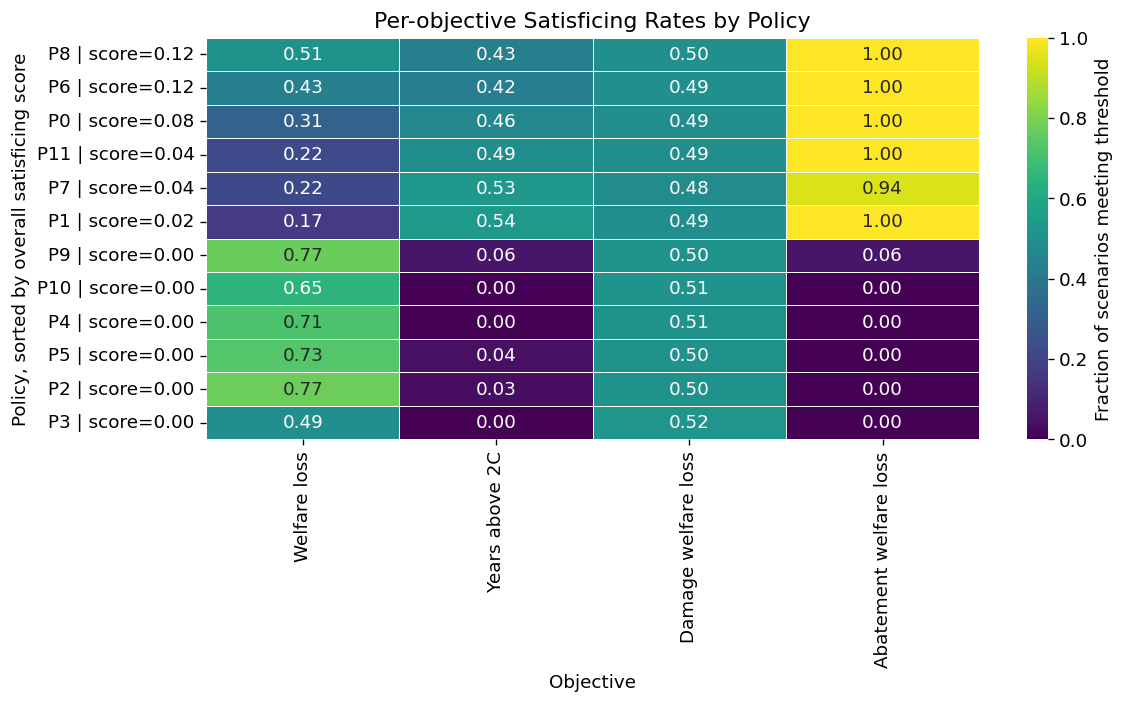

In [13]:

# ---------------------------------------------------------------------------
# Task 1: Choose thresholds
# ---------------------------------------------------------------------------
# All four re-evaluation objectives are minimised: lower = better.
#
# years_above_2C uses an external standard: staying below 2C.
# The welfare objectives use percentile-based thresholds because there is no
# obvious universal external cutoff in the model's welfare units.

thresholds = {
    "welfare": np.nanpercentile(reeval_results[:, :, OBJECTIVES.index("welfare")], 50),
    "years_above_2C": np.nanpercentile(reeval_results[:, :, OBJECTIVES.index("years_above_2C")], 25),
    "welfare_loss_damage": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("welfare_loss_damage")], 50
    ),
    "welfare_loss_abatement": np.nanpercentile(
        reeval_results[:, :, OBJECTIVES.index("welfare_loss_abatement")], 50
    ),
}

threshold_reasoning = {
    "welfare": "Median threshold across all policy-scenario pairs because welfare loss has no external policy target.",
    "years_above_2C": "External Paris-aligned threshold: acceptable means never exceeding 2C.",
    "welfare_loss_damage": "Median threshold across all policy-scenario pairs because damage welfare loss has no direct external unit-based standard.",
    "welfare_loss_abatement": "Median threshold across all policy-scenario pairs because abatement welfare loss has no direct external unit-based standard.",
}

threshold_table = pd.DataFrame({
    "objective": OBJECTIVES,
    "threshold": [thresholds[obj] for obj in OBJECTIVES],
    "direction": ["lower is better"] * len(OBJECTIVES),
    "reasoning": [threshold_reasoning[obj] for obj in OBJECTIVES],
})

display(threshold_table)

# ---------------------------------------------------------------------------
# Task 2: Compute satisficing matrix
# ---------------------------------------------------------------------------

threshold_array = np.array([thresholds[obj] for obj in OBJECTIVES])

# Shape: (n_policies, n_scenarios, n_objectives)
meets_objective = reeval_results <= threshold_array

# Shape: (n_policies, n_scenarios)
# True only if all four objectives meet their thresholds in that scenario.
satisficing_matrix = meets_objective.all(axis=2)

print("Satisficing matrix shape:", satisficing_matrix.shape)

# ---------------------------------------------------------------------------
# Task 3: Compute and report satisficing scores
# ---------------------------------------------------------------------------

satisficing_scores = satisficing_matrix.mean(axis=1)

per_objective_rate = meets_objective.mean(axis=(0, 1))

summary = pd.DataFrame({
    "metric": [
        "Mean satisficing score",
        "Maximum satisficing score",
        "Policies with zero satisficing score",
    ],
    "value": [
        satisficing_scores.mean(),
        satisficing_scores.max(),
        int((satisficing_scores == 0).sum()),
    ],
})

display(summary)

per_objective_table = pd.DataFrame({
    "objective": OBJECTIVES,
    "threshold": threshold_array,
    "fraction_meeting_threshold": per_objective_rate,
}).sort_values("fraction_meeting_threshold")

display(per_objective_table)

hardest_objective = per_objective_table.iloc[0]["objective"]
print(f"Hardest objective to satisfy: {hardest_objective}")

# ---------------------------------------------------------------------------
# Task 4: Heatmap of per-objective satisficing rates
# ---------------------------------------------------------------------------

# For each policy and objective: fraction of scenarios meeting that objective.
# Shape: (n_policies, n_objectives)
policy_objective_rates = meets_objective.mean(axis=1)

sort_idx = np.argsort(satisficing_scores)[::-1]

heatmap_df = pd.DataFrame(
    policy_objective_rates[sort_idx],
    columns=[objective_labels[obj] for obj in OBJECTIVES],
    index=[f"P{i} | score={satisficing_scores[i]:.2f}" for i in sort_idx],
)

plt.figure(figsize=(10, max(6, 0.35 * n_policies)))
sns.heatmap(
    heatmap_df,
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Fraction of scenarios meeting threshold"},
)

plt.title("Per-objective Satisficing Rates by Policy")
plt.xlabel("Objective")
plt.ylabel("Policy, sorted by overall satisficing score")
plt.tight_layout()
plt.show()

## Step 3 — Minimax Regret

Satisficing tells you whether a policy is *acceptable*. Minimax regret tells
you which policy has the **smallest worst-case loss** — the one that never
performs catastrophically relative to what was achievable in that scenario.

**Task 1. Compute the per-scenario ideal and anti-ideal.**
For each scenario, find the best and worst value any policy achieves on each
objective. These define the range of performance possible in that scenario.

**Task 2. Compute normalised regret.**
For each (policy, scenario, objective), regret is how far that policy
falls short of the best achievable outcome in that scenario, expressed as a
fraction of the full range. (You can subtract the ideal from each policy's result, then divide by the range (anti-ideal − ideal) computed in Task 1). A regret of 0 means the policy matched the best
possible outcome; a regret of 1 means it achieved the worst possible outcome.

**Task 3. Compute maximum regret per policy.**
For each policy, take the worst-case total regret across all scenarios. This
is the **maximum regret** — the single number that summarises how badly the
policy could perform in the worst climate future.

**Task 4. Identify the minimax-regret policy.**
Sort policies by maximum regret. The policy with the lowest maximum regret is
the most robust choice under this criterion.

**Task 5. Plot a CDF of maximum regret**
Plot the cumulative distribution function of maximum regret across all
policies (x = maximum regret, y = fraction of policies with regret ≤ x).
Mark the minimax-regret policy with a vertical line.

This plot shows the full spread of robustness across the Pareto front —
whether most policies are similarly robust or whether there is a wide range.


Ideal shape: (1000, 4)
Anti-ideal shape: (1000, 4)
Normalised regret shape: (8, 1000, 4)


,policy,maximum_regret,mean_regret,satisficing_score
0,P0,3.000000,1.503159,0.0
1,P1,3.000000,0.674297,0.0
2,P2,3.008203,0.713723,0.0
4,P4,3.035365,0.851367,0.0
3,P3,3.049116,0.831519,0.0
6,P6,3.051108,0.882267,0.0
7,P7,3.109231,0.895290,0.0
5,P5,3.178257,0.919416,0.0


Minimax-regret policy: P0
Maximum regret: 3.000
Mean regret: 1.503


,objective,mean_normalised_regret
0,welfare,0.347973
1,years_above_2C,0.000000
2,welfare_loss_damage,0.155186
3,welfare_loss_abatement,1.000000


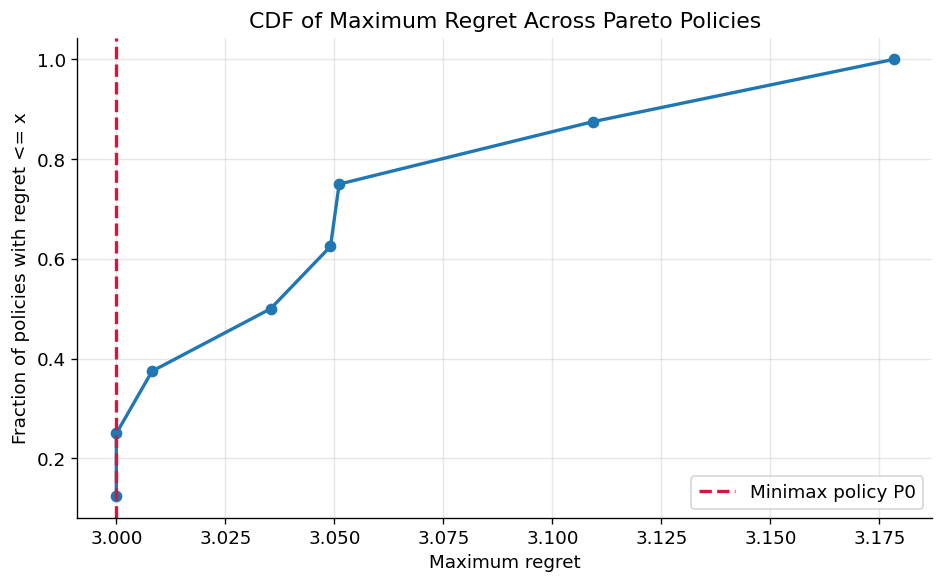

In [ ]:

# ---------------------------------------------------------------------------
# Step 3: Minimax regret
# ---------------------------------------------------------------------------
# All four re-evaluation objectives are minimised, so:
# ideal      = lowest value achieved by any policy in that scenario
# anti-ideal = highest value achieved by any policy in that scenario

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Shape reminder:
# reeval_results = (n_policies, n_scenarios, n_objectives)

n_policies, n_scenarios, n_objectives = reeval_results.shape

# ---------------------------------------------------------------------------
# Task 1: Per-scenario ideal and anti-ideal
# ---------------------------------------------------------------------------

ideal = np.nanmin(reeval_results, axis=0)       # shape: (n_scenarios, n_objectives)
anti_ideal = np.nanmax(reeval_results, axis=0)  # shape: (n_scenarios, n_objectives)

regret_range = anti_ideal - ideal

# Avoid division by zero if all policies perform identically on an objective
regret_range = np.where(regret_range == 0, 1.0, regret_range)

print("Ideal shape:", ideal.shape)
print("Anti-ideal shape:", anti_ideal.shape)

# ---------------------------------------------------------------------------
# Task 2: Normalised regret
# ---------------------------------------------------------------------------
# Broadcasting:
# reeval_results: (n_policies, n_scenarios, n_objectives)
# ideal:          (            n_scenarios, n_objectives)

normalised_regret = (reeval_results - ideal) / regret_range

# Numerical cleanup
normalised_regret = np.clip(normalised_regret, 0, 1)

print("Normalised regret shape:", normalised_regret.shape)

# Optional: total regret across objectives for every policy-scenario pair
# Shape: (n_policies, n_scenarios)
total_regret = normalised_regret.sum(axis=2)

# ---------------------------------------------------------------------------
# Task 3: Max6imum regret per policy
# ---------------------------------------------------------------------------
# Worst climate future for each policy

maximum_regret = np.nanmax(total_regret, axis=1)

# Also useful: average regret across scenarios
mean_regret = np.nanmean(total_regret, axis=1)

# ---------------------------------------------------------------------------
# Task 4: Identify minimax-regret policy
# ---------------------------------------------------------------------------

sorted_policy_idx = np.argsort(maximum_regret)
minimax_policy_idx = sorted_policy_idx[0]

regret_table = pd.DataFrame({
    "policy": [f"P{i}" for i in range(n_policies)],
    "maximum_regret": maximum_regret,
    "mean_regret": mean_regret,
    "satisficing_score": satisficing_scores if "satisficing_scores" in globals() else np.nan,
}).sort_values("maximum_regret")

display(regret_table.head(10))

print(f"Minimax-regret policy: P{minimax_policy_idx}")
print(f"Maximum regret: {maximum_regret[minimax_policy_idx]:.3f}")
print(f"Mean regret: {mean_regret[minimax_policy_idx]:.3f}")

# Per-objective regret for the minimax policy
minimax_objective_regret = normalised_regret[minimax_policy_idx].mean(axis=0)

minimax_detail = pd.DataFrame({
    "objective": OBJECTIVES,
    "mean_normalised_regret": minimax_objective_regret,
})

display(minimax_detail)

# ---------------------------------------------------------------------------
# Task 5: Plot CDF of maximum regret
# ---------------------------------------------------------------------------

x = np.sort(maximum_regret)
y = np.arange(1, n_policies + 1) / n_policies

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker="o", linewidth=2)

plt.axvline(
    maximum_regret[minimax_policy_idx],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Minimax policy P{minimax_policy_idx}",
)

plt.xlabel("Maximum regret")
plt.ylabel("Fraction of policies with regret <= x")
plt.title("CDF of Maximum Regret Across Pareto Policies")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




## Reflection Questions

**How does the minimax-regret policy compares to the best satisficing policy? are they the same policy or different ones?**
currently all policies have a satisficing score of 0
**What does this tell you about your selected robustness method?**
Cant tell yet
**Which single policy would you recommend, and why?**
Currently policy 1 as it is scores best or equally best across all metrics

In [13]:
def evaluate_policy_with_backstop(policy_row, backstop_cost=550, n_ensemble=10):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center_{i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii_{i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, n_ensemble, dtype=int))

    JUSTICE.hard_reset()

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )

    model.abatement = AbatementEnerdata(
        input_dataset=model.data_loader,
        time_horizon=model.time_horizon,
        scenario=model.scenario,
        backstop_cost=backstop_cost,
    )

    no_ens = model.no_of_ensembles

    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)

    prev_temp = np.zeros(no_ens)
    diff = np.zeros(no_ens)

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )

        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )

        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    data = model.evaluate()

    welfare = float(np.abs(data["welfare"]))

    years_above = float(
        years_above_temperature_threshold(
            data["global_temperature"],
            threshold=2.0,
        )
    )

    _, _, _, wl_damage = model.welfare_function.calculate_welfare(
        data["damage_cost_per_capita"],
        welfare_loss=True,
    )

    _, _, _, wl_abatement = model.welfare_function.calculate_welfare(
        data["abatement_cost_per_capita"],
        welfare_loss=True,
    )

    return {
        "welfare": welfare,
        "years_above_2C": years_above,
        "welfare_loss_damage": float(np.abs(wl_damage)),
        "welfare_loss_abatement": float(np.abs(wl_abatement)),
    }

In [16]:
backstop_values = [550, 400, 300, 50]

rows = []

for backstop_cost in backstop_values:
    print(f"Evaluating backstop_cost={backstop_cost}")

    outcomes = []

    for i, policy_row in ref_set.iterrows():
        result = evaluate_policy_with_backstop(
            policy_row,
            backstop_cost=backstop_cost,
            n_ensemble=10,
        )

        outcomes.append([result[obj] for obj in OBJECTIVES])

    outcomes = np.array(outcomes)

    # Shape becomes policy x objective.
    # This is a single re-evaluation per policy, so no scenario axis here.
    meets_objective = outcomes <= np.array([thresholds[obj] for obj in OBJECTIVES])
    satisficing = meets_objective.all(axis=1)
    satisficing_scores = satisficing.astype(float)

    rows.append({
        "backstop_cost": backstop_cost,
        "mean_satisficing_score": satisficing_scores.mean(),
        "max_satisficing_score": satisficing_scores.max(),
        "n_satisficing_policies": int(satisficing.sum()),
        "best_policy": int(np.argmax(satisficing_scores)),
    })

backstop_satisficing = pd.DataFrame(rows)
display(backstop_satisficing)

Evaluating backstop_cost=550


NameError: name 'ref_set' is not defined

In [ ]:
objective_rows = []

for backstop_cost in backstop_values:
    print(f"Evaluating backstop_cost={backstop_cost}")

    outcomes = []

    for i, policy_row in ref_set.iterrows():
        result = evaluate_policy_with_backstop(
            policy_row,
            backstop_cost=backstop_cost,
            n_ensemble=10,
        )
        outcomes.append([result[obj] for obj in OBJECTIVES])

    outcomes = np.array(outcomes)

    for oi, obj in enumerate(OBJECTIVES):
        objective_rows.append({
            "backstop_cost": backstop_cost,
            "objective": obj,
            "mean": np.nanmean(outcomes[:, oi]),
            "min": np.nanmin(outcomes[:, oi]),
            "max": np.nanmax(outcomes[:, oi]),
        })

backstop_objectives = pd.DataFrame(objective_rows)
display(backstop_objectives)